# Ultra-Lightweight Arrhythmia Detection Starter Notebook

This notebook is a **starting pipeline** for the project:

**MIT-BIH ECG data → preprocessing/windowing → baseline 1D-CNN → pruning → INT8 quantization → benchmark**

Goal: get a working baseline first, then add compression and deployment steps.

## 0. Install dependencies

Run once in a fresh environment. Skip if already installed.

In [ ]:
# Install tf_keras to provide legacy Keras 2 support for TFMOT
!pip install wfdb tensorflow-model-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but

## 1. Imports and configuration

In [ ]:
import os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import wfdb
import tensorflow as tf
from tensorflow.keras import layers, models
warnings.filterwarnings("ignore")
print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
Num GPUs: 1


In [ ]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# You can expand this list later for higher accuracy.
RECORDS = ['100','101','102','103','104','105','106','107','108','109']

WINDOW_SIZE = 256
HALF_WINDOW = WINDOW_SIZE // 2
TARGET_LEAD = 0

# Multi-class AAMI-style mapping
# N: Normal
# S: Supraventricular ectopic
# V: Ventricular ectopic
# F: Fusion beat
# Q: Unknown / paced / others

LABEL_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',

    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',

    'V': 'V', 'E': 'V',

    'F': 'F',

    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASS_NAMES)}

BATCH_SIZE = 64
EPOCHS = 10
VALIDATION_SIZE = 0.2
TEST_SIZE = 0.2

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)


## 2. Load MIT-BIH records

This uses `wfdb` to stream records from PhysioNet. Internet access is required the first time.

In [ ]:
def load_mitbih_record(record_id, pn_dir='mitdb'):
    # Load ECG signal and annotations for one MIT-BIH record.
    record = wfdb.rdrecord(record_id, pn_dir=pn_dir)
    ann = wfdb.rdann(record_id, 'atr', pn_dir=pn_dir)
    signal = record.p_signal[:, TARGET_LEAD].astype(np.float32)
    fs = record.fs
    return signal, ann.sample, ann.symbol, fs

signal, r_peaks, symbols, fs = load_mitbih_record(RECORDS[0])
print("Record:", RECORDS[0])
print("Signal shape:", signal.shape)
print("Sampling frequency:", fs)
print("First 10 annotations:", list(zip(r_peaks[:10], symbols[:10])))

Record: 100
Signal shape: (650000,)
Sampling frequency: 360
First 10 annotations: [(18, '+'), (77, 'N'), (370, 'N'), (662, 'N'), (946, 'N'), (1231, 'N'), (1515, 'N'), (1809, 'N'), (2044, 'A'), (2402, 'N')]


## 3. Visualize a raw ECG segment

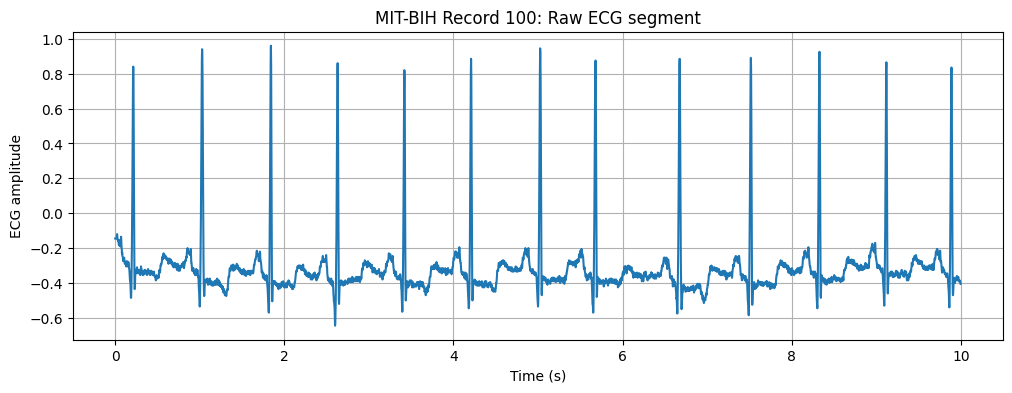

In [ ]:
plt.figure(figsize=(12, 4))
start = 0
end = min(len(signal), fs * 10)
plt.plot(np.arange(start, end) / fs, signal[start:end])
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.title(f"MIT-BIH Record {RECORDS[0]}: Raw ECG segment")
plt.grid(True)
plt.show()

## 4. Preprocessing: filtering, normalization, and beat-window extraction

Pipeline:
1. Bandpass filter ECG signal.
2. Normalize each full record.
3. Around each annotated beat, crop a fixed-length window.
4. Convert MIT-BIH symbols into multi-class AAMI labels.


In [ ]:

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)

def normalize_signal(signal, eps=1e-8):
    return ((signal - np.mean(signal)) / (np.std(signal) + eps)).astype(np.float32)

def symbol_to_multiclass_label(symbol):
    if symbol not in LABEL_MAP:
        return None
    mapped = LABEL_MAP[symbol]
    return CLASS_TO_INDEX[mapped]

def extract_windows_from_record(record_id):
    signal, r_peaks, symbols, fs = load_mitbih_record(record_id)

    filtered = bandpass_filter(signal, fs)
    normalized = normalize_signal(filtered)

    windows = []
    labels = []

    for peak, symbol in zip(r_peaks, symbols):
        label = symbol_to_multiclass_label(symbol)

        if label is None:
            continue

        start = peak - HALF_WINDOW
        end = peak + HALF_WINDOW

        if start < 0 or end >= len(normalized):
            continue

        window = normalized[start:end]

        if len(window) != WINDOW_SIZE:
            continue

        windows.append(window.reshape(-1, 1))
        labels.append(label)

    return np.array(windows, dtype=np.float32), np.array(labels, dtype=np.int32)


In [ ]:

import time

all_X, all_y, record_counts = [], [], []
MAX_RETRIES = 3

for rec in RECORDS:
    success = False

    for i in range(MAX_RETRIES):
        try:
            X_rec, y_rec = extract_windows_from_record(rec)

            all_X.append(X_rec)
            all_y.append(y_rec)

            class_counts = {
                CLASS_NAMES[k]: int(np.sum(y_rec == k))
                for k in range(len(CLASS_NAMES))
            }

            record_counts.append({
                "record": rec,
                "num_windows": len(y_rec),
                **class_counts
            })

            print(f"Loaded record {rec}: {len(y_rec)} windows")
            success = True
            break

        except Exception as e:
            print(f"Retry {i+1}/{MAX_RETRIES} failed for {rec}: {e}")
            time.sleep(2)

    if not success:
        print(f"Skipping record {rec}")

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

print("Final dataset shape:", X.shape)
print("Label distribution:")

for k, v in zip(*np.unique(y, return_counts=True)):
    print(CLASS_NAMES[k], ":", v)

pd.DataFrame(record_counts)


Loaded record 100: 2271 windows
Loaded record 101: 1864 windows
Loaded record 102: 2187 windows
Loaded record 103: 2083 windows
Loaded record 104: 2227 windows
Loaded record 105: 2572 windows
Loaded record 106: 2027 windows
Loaded record 107: 2136 windows
Loaded record 108: 1762 windows
Loaded record 109: 2530 windows
Final dataset shape: (21659, 256, 1)
Label distribution:
N : 14701
S : 42
V : 682
F : 4
Q : 6230


,record,num_windows,N,S,V,F,Q
0,100,2271,2237,33,1,0,0
1,101,1864,1859,3,0,0,2
2,102,2187,99,0,4,0,2084
3,103,2083,2081,2,0,0,0
4,104,2227,163,0,2,0,2062
5,105,2572,2526,0,41,0,5
6,106,2027,1507,0,520,0,0
7,107,2136,0,0,59,0,2077
8,108,1762,1739,4,17,2,0
9,109,2530,2490,0,38,2,0


## 5. Visualize sample windows

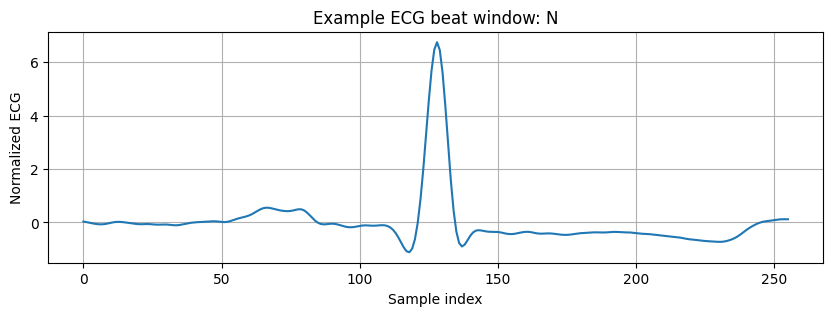

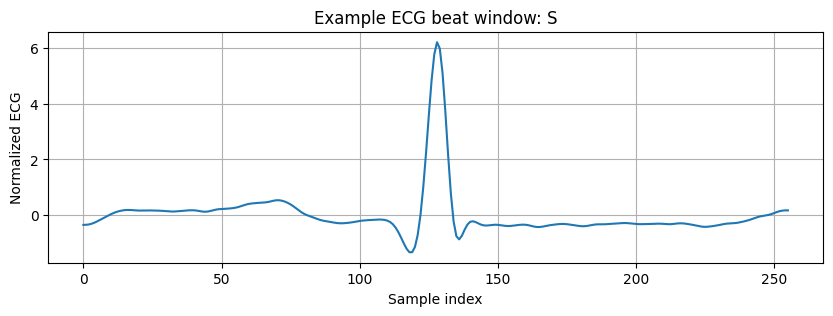

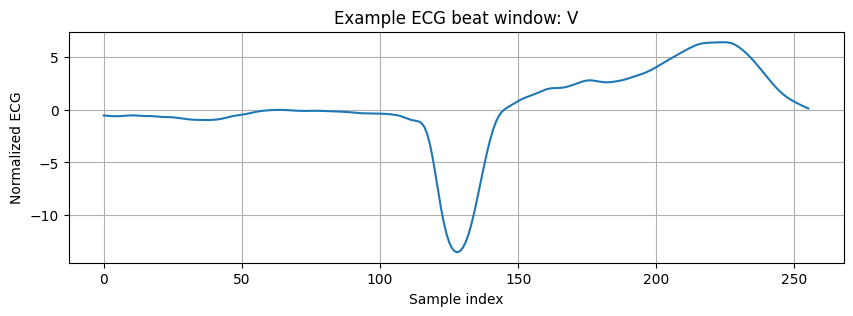

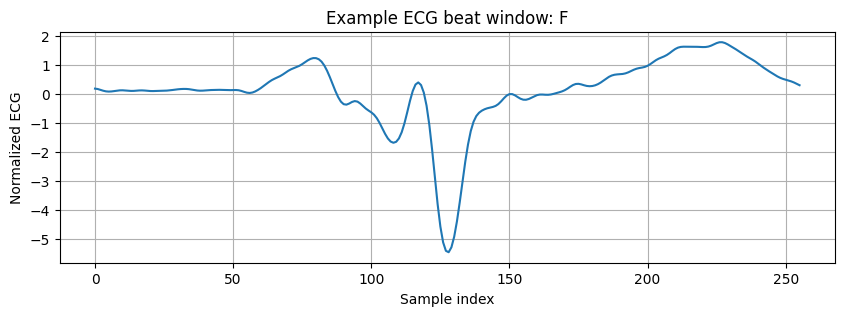

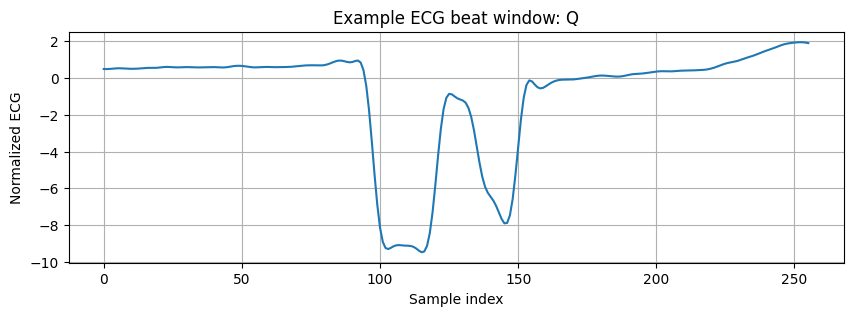

In [ ]:
def plot_sample_window(label_value, title):
    idxs = np.where(y == label_value)[0]

    if len(idxs) == 0:
        print(f"No samples for label {label_value}")
        return

    idx = idxs[0]

    plt.figure(figsize=(10, 3))
    plt.plot(X[idx, :, 0])
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Normalized ECG")
    plt.grid(True)
    plt.show()

for i, class_name in enumerate(CLASS_NAMES):
    plot_sample_window(i, f"Example ECG beat window: {class_name}")


## 6. Train/validation/test split

For a stronger experiment, split by patient/record rather than random beat windows. This starter uses random split for simplicity.

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=VALIDATION_SIZE, random_state=SEED, stratify=y_trainval)
print("Train:", X_train.shape, dict(zip(*np.unique(y_train, return_counts=True))))
print("Val:  ", X_val.shape, dict(zip(*np.unique(y_val, return_counts=True))))
print("Test: ", X_test.shape, dict(zip(*np.unique(y_test, return_counts=True))))

Train: (13861, 256, 1) {0: 9408, 1: 27, 2: 436, 3: 3, 4: 3987}
Val:   (3466, 256, 1) {0: 2353, 1: 7, 2: 109, 4: 997}
Test:  (4332, 256, 1) {0: 2940, 1: 8, 2: 137, 3: 1, 4: 1246}


## 7. Training-only augmentation for rare classes

This augments only `X_train` / `y_train` after the train/validation/test split. Validation and test data stay untouched so the evaluation remains clean.


In [ ]:
RARE_CLASS_NAMES = ['S', 'V', 'F']
RARE_CLASS_INDICES = [CLASS_TO_INDEX[name] for name in RARE_CLASS_NAMES]

AUGMENT_TARGET_RATIO_OF_MAJORITY = 0.25
AUGMENT_MAX_TARGET_PER_CLASS = 2000
AUGMENT_NOISE_STD = 0.03
AUGMENT_MAX_SHIFT = 8
AUGMENT_BASELINE_WANDER_STD = 0.02
AUGMENT_AMPLITUDE_RANGE = (0.90, 1.10)


def class_count_dict(labels):
    counts = np.bincount(labels, minlength=len(CLASS_NAMES))
    return {CLASS_NAMES[i]: int(counts[i]) for i in range(len(CLASS_NAMES))}


def zscore_window(window, eps=1e-8):
    window = window.astype(np.float32)
    return (window - np.mean(window)) / (np.std(window) + eps)


def shift_without_wrap(x, shift):
    if shift == 0:
        return x

    shifted = np.roll(x, shift)
    if shift > 0:
        shifted[:shift] = shifted[shift]
    else:
        shifted[shift:] = shifted[shift - 1]
    return shifted


def augment_ecg_window(window, rng):
    x = window[:, 0].astype(np.float32).copy()

    amplitude = rng.uniform(*AUGMENT_AMPLITUDE_RANGE)
    x = x * amplitude

    shift = int(rng.integers(-AUGMENT_MAX_SHIFT, AUGMENT_MAX_SHIFT + 1))
    x = shift_without_wrap(x, shift)

    noise = rng.normal(0.0, AUGMENT_NOISE_STD, size=x.shape).astype(np.float32)
    x = x + noise

    phase = rng.uniform(0.0, 2.0 * np.pi)
    baseline = AUGMENT_BASELINE_WANDER_STD * np.sin(
        np.linspace(0.0, 2.0 * np.pi, len(x), dtype=np.float32) + phase
    )
    x = x + baseline.astype(np.float32)

    x = zscore_window(x)
    return x.reshape(WINDOW_SIZE, 1).astype(np.float32)


def make_augmented_training_set(X_source, y_source, rare_class_indices, target_count, seed):
    rng = np.random.default_rng(seed)
    augmented_X = [X_source.astype(np.float32)]
    augmented_y = [y_source.astype(np.int64)]

    for class_idx in rare_class_indices:
        class_X = X_source[y_source == class_idx]
        current_count = len(class_X)

        if current_count == 0:
            print(f"Skipping {CLASS_NAMES[class_idx]}: no training samples available")
            continue

        samples_to_generate = max(0, target_count - current_count)
        if samples_to_generate == 0:
            continue

        sampled_indices = rng.integers(0, current_count, size=samples_to_generate)
        generated_X = np.stack([
            augment_ecg_window(class_X[idx], rng)
            for idx in sampled_indices
        ])
        generated_y = np.full(samples_to_generate, class_idx, dtype=np.int64)

        augmented_X.append(generated_X)
        augmented_y.append(generated_y)

        print(
            f"Augmented {CLASS_NAMES[class_idx]}: "
            f"{current_count} -> {current_count + samples_to_generate}"
        )

    X_out = np.concatenate(augmented_X, axis=0)
    y_out = np.concatenate(augmented_y, axis=0)

    order = rng.permutation(len(y_out))
    return X_out[order], y_out[order]


train_counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
majority_count = int(train_counts.max())
rare_existing_max = int(train_counts[RARE_CLASS_INDICES].max())
augment_target_count = min(
    AUGMENT_MAX_TARGET_PER_CLASS,
    int(np.ceil(majority_count * AUGMENT_TARGET_RATIO_OF_MAJORITY)),
)
augment_target_count = max(augment_target_count, rare_existing_max)

print("Original train:", X_train.shape, class_count_dict(y_train))
print("Val unchanged: ", X_val.shape, class_count_dict(y_val))
print("Test unchanged:", X_test.shape, class_count_dict(y_test))
print("Rare-class augmentation target per class:", augment_target_count)

X_train_aug, y_train_aug = make_augmented_training_set(
    X_train,
    y_train,
    rare_class_indices=RARE_CLASS_INDICES,
    target_count=augment_target_count,
    seed=SEED,
)

print("Augmented train:", X_train_aug.shape, class_count_dict(y_train_aug))


Original train: (13861, 256, 1) {'N': 9408, 'S': 27, 'V': 436, 'F': 3, 'Q': 3987}
Val unchanged:  (3466, 256, 1) {'N': 2353, 'S': 7, 'V': 109, 'F': 0, 'Q': 997}
Test unchanged: (4332, 256, 1) {'N': 2940, 'S': 8, 'V': 137, 'F': 1, 'Q': 1246}
Rare-class augmentation target per class: 2000
Augmented S: 27 -> 2000
Augmented V: 436 -> 2000
Augmented F: 3 -> 2000
Augmented train: (19395, 256, 1) {'N': 9408, 'S': 2000, 'V': 2000, 'F': 2000, 'Q': 3987}


## 8. Build baseline 1D-CNN

In [ ]:

def build_baseline_1dcnn(input_shape=(WINDOW_SIZE, 1), num_classes=len(CLASS_NAMES)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(16, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_model = build_baseline_1dcnn()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 256, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,829 (54.02 KB)

 Trainable params: 13,605 (53.14 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
history = baseline_model.fit(X_train_aug, y_train_aug, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)

Epoch 1/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9123 - loss: 0.3412 - val_accuracy: 0.1018 - val_loss: 2.3913
Epoch 2/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9808 - loss: 0.0789 - val_accuracy: 0.9694 - val_loss: 0.1226
Epoch 3/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9870 - loss: 0.0559 - val_accuracy: 0.9893 - val_loss: 0.0421
Epoch 4/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0413 - val_accuracy: 0.4564 - val_loss: 2.1146
Epoch 5/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9891 - loss: 0.0424 - val_accuracy: 0.9916 - val_loss: 0.0318
Epoch 6/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9921 - loss: 0.0325 - val_accuracy: 0.9873 - val_loss: 0.0482
Epoch 7/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0315 - val_accuracy: 0.3304 - val_loss: 2.9179
Epoch 8/10
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9936 - loss: 0.0256 - val_accuracy: 

## 9. Evaluate baseline model

In [ ]:

def evaluate_keras_model(model, X_eval, y_eval, name="model"):
    probs = model.predict(X_eval, batch_size=BATCH_SIZE, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_eval, preds)

    print(f"{name} accuracy: {acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_eval, preds, target_names=CLASS_NAMES))

    print("Confusion matrix:")
    print(confusion_matrix(y_eval, preds))

    return acc

baseline_acc = evaluate_keras_model(
    baseline_model,
    X_test,
    y_test,
    name="Baseline FP32 Multi-class 1D-CNN"
)


Baseline FP32 Multi-class 1D-CNN accuracy: 0.9938

Classification report:
              precision    recall  f1-score   support

           N       0.99      1.00      1.00      2940
           S       0.75      0.38      0.50         8
           V       0.96      0.96      0.96       137
           F       0.00      0.00      0.00         1
           Q       1.00      1.00      1.00      1246

    accuracy                           0.99      4332
   macro avg       0.74      0.66      0.69      4332
weighted avg       0.99      0.99      0.99      4332

Confusion matrix:
[[2929    0    6    0    5]
 [   5    3    0    0    0]
 [   5    1  131    0    0]
 [   1    0    0    0    0]
 [   4    0    0    0 1242]]


In [ ]:
baseline_path = ARTIFACT_DIR / "baseline_1dcnn.keras"
baseline_model.save(baseline_path)
print("Saved:", baseline_path)
print("File size KB:", baseline_path.stat().st_size / 1024)

Saved: artifacts/baseline_1dcnn.keras
File size KB: 221.4150390625


## 10. Baseline latency benchmark

In [ ]:
def benchmark_keras_latency(model, sample, num_runs=200, warmup=20):
    sample = sample.astype(np.float32)
    for _ in range(warmup):
        _ = model.predict(sample, verbose=0)
    start = time.perf_counter()
    for _ in range(num_runs):
        _ = model.predict(sample, verbose=0)
    end = time.perf_counter()
    return (end - start) * 1000 / num_runs

sample = X_test[:1]
baseline_latency_ms = benchmark_keras_latency(baseline_model, sample)
print(f"Baseline average latency: {baseline_latency_ms:.3f} ms/sample")

Baseline average latency: 74.589 ms/sample


## 11. Pruning

This uses TensorFlow Model Optimization Toolkit pruning. It is a practical compression baseline.

In [ ]:
try:
    import tensorflow_model_optimization as tfmot
    TFMOT_AVAILABLE = True
except Exception as e:
    print("tensorflow-model-optimization not available:", e)
    TFMOT_AVAILABLE = False

In [ ]:
if TFMOT_AVAILABLE:
    import tf_keras
    import tensorflow_model_optimization as tfmot

    # Use tf_keras (Legacy Keras 2) to ensure compatibility with tfmot
    def build_legacy_1dcnn(input_shape=(WINDOW_SIZE, 1), num_classes=len(CLASS_NAMES)):
        model = tf_keras.Sequential([
            tf_keras.layers.InputLayer(input_shape=input_shape),
            tf_keras.layers.Conv1D(16, kernel_size=5, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.MaxPooling1D(pool_size=2),
            tf_keras.layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.MaxPooling1D(pool_size=2),
            tf_keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
            tf_keras.layers.BatchNormalization(),
            tf_keras.layers.GlobalAveragePooling1D(),
            tf_keras.layers.Dense(32, activation='relu'),
            tf_keras.layers.Dropout(0.2),
            tf_keras.layers.Dense(num_classes, activation='softmax')
        ])
        return model

    prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

    # Create model using legacy Keras
    base_model_for_pruning = build_legacy_1dcnn()

    steps_per_epoch = int(np.ceil(len(X_train_aug) / BATCH_SIZE))
    end_step = steps_per_epoch * max(1, EPOCHS // 2)
    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=0.50,
            begin_step=0,
            end_step=end_step
        )
    }

    # Apply pruning to the legacy model
    pruned_model = prune_low_magnitude(base_model_for_pruning, **pruning_params)

    pruned_model.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    pruning_callbacks = [
        tfmot.sparsity.keras.UpdatePruningStep(),
        tf_keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    ]

    pruned_history = pruned_model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=pruning_callbacks,
        verbose=1
    )

    stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    # Note: stripped_pruned_model is a tf_keras model
    stripped_pruned_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    stripped_pruned_model = None

Epoch 1/10
304/304 [==============================] - 17s 27ms/step - loss: 0.3262 - accuracy: 0.9175 - val_loss: 2.2595 - val_accuracy: 0.6786
Epoch 2/10
304/304 [==============================] - 3s 10ms/step - loss: 0.1126 - accuracy: 0.9700 - val_loss: 3.2369 - val_accuracy: 0.2902
Epoch 3/10
304/304 [==============================] - 4s 13ms/step - loss: 0.0939 - accuracy: 0.9761 - val_loss: 0.0661 - val_accuracy: 0.9850
Epoch 4/10
304/304 [==============================] - 4s 12ms/step - loss: 0.0596 - accuracy: 0.9853 - val_loss: 2.8209 - val_accuracy: 0.2802
Epoch 5/10
304/304 [==============================] - 3s 10ms/step - loss: 0.0574 - accuracy: 0.9859 - val_loss: 0.0496 - val_accuracy: 0.9841
Epoch 6/10
304/304 [==============================] - 3s 10ms/step - loss: 0.0452 - accuracy: 0.9885 - val_loss: 0.0408 - val_accuracy: 0.9902
Epoch 7/10
304/304 [==============================] - 4s 14ms/step - loss: 0.0366 - accuracy: 0.9913 - val_loss: 0.0260 - val_accuracy: 0.993

In [ ]:
if stripped_pruned_model is not None:
    pruned_acc = evaluate_keras_model(stripped_pruned_model, X_test, y_test, name="Pruned 1D-CNN")
    pruned_path = ARTIFACT_DIR / "pruned_1dcnn.keras"
    stripped_pruned_model.save(pruned_path)
    pruned_latency_ms = benchmark_keras_latency(stripped_pruned_model, sample)
    print("Saved:", pruned_path)
    print("Pruned model size KB:", pruned_path.stat().st_size / 1024)
    print(f"Pruned average latency: {pruned_latency_ms:.3f} ms/sample")
else:
    pruned_acc = None
    pruned_latency_ms = None

Pruned 1D-CNN accuracy: 0.9933

Classification report:
              precision    recall  f1-score   support

           N       0.99      1.00      1.00      2940
           S       1.00      0.38      0.55         8
           V       0.96      0.95      0.96       137
           F       0.00      0.00      0.00         1
           Q       1.00      1.00      1.00      1246

    accuracy                           0.99      4332
   macro avg       0.79      0.66      0.70      4332
weighted avg       0.99      0.99      0.99      4332

Confusion matrix:
[[2929    0    5    0    6]
 [   5    3    0    0    0]
 [   7    0  130    0    0]
 [   1    0    0    0    0]
 [   5    0    0    0 1241]]
Saved: artifacts/pruned_1dcnn.keras
Pruned model size KB: 87.8369140625
Pruned average latency: 56.776 ms/sample


## 12. TFLite INT8 quantization

This converts the pruned model to INT8 TFLite. If pruning is skipped, it converts the baseline model.

In [ ]:
def representative_dataset():
    n = min(200, len(X_train_aug))
    for i in range(n):
        yield [X_train_aug[i:i+1].astype(np.float32)]

source_model_for_tflite = stripped_pruned_model if stripped_pruned_model is not None else baseline_model
converter = tf.lite.TFLiteConverter.from_keras_model(source_model_for_tflite)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()
tflite_path = ARTIFACT_DIR / "ecg_1dcnn_pruned_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_int8_model)
print("Saved:", tflite_path)
print("TFLite INT8 size KB:", tflite_path.stat().st_size / 1024)

Saved: artifacts/ecg_1dcnn_pruned_int8.tflite
TFLite INT8 size KB: 24.9375


## 13. Evaluate TFLite INT8 model

In [ ]:
def evaluate_tflite_int8(tflite_model_path, X_eval, y_eval):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    preds = []
    for x in X_eval:
        x = x[np.newaxis, ...].astype(np.float32)
        if input_details['dtype'] == np.int8:
            x_q = np.round(x / input_scale + input_zero_point).astype(np.int8)
        else:
            x_q = x.astype(input_details['dtype'])
        interpreter.set_tensor(input_details['index'], x_q)
        interpreter.invoke()
        y_q = interpreter.get_tensor(output_details['index'])
        if output_details['dtype'] == np.int8:
            y_float = (y_q.astype(np.float32) - output_zero_point) * output_scale
        else:
            y_float = y_q
        preds.append(int(np.argmax(y_float, axis=1)[0]))
    preds = np.asarray(preds)
    acc = accuracy_score(y_eval, preds)
    print(f"TFLite INT8 accuracy: {acc:.4f}")
    print(classification_report(y_eval, preds, target_names=CLASS_NAMES))
    print(confusion_matrix(y_eval, preds))
    return acc

int8_acc = evaluate_tflite_int8(tflite_path, X_test, y_test)

TFLite INT8 accuracy: 0.7325
              precision    recall  f1-score   support

           N       0.99      0.63      0.77      2940
           S       0.06      0.25      0.09         8
           V       0.97      0.66      0.78       137
           F       0.00      1.00      0.00         1
           Q       0.96      0.99      0.98      1246

    accuracy                           0.73      4332
   macro avg       0.60      0.71      0.52      4332
weighted avg       0.98      0.73      0.83      4332

[[1842   34    3 1029   32]
 [   3    2    0    3    0]
 [   9    0   90   20   18]
 [   0    0    0    1    0]
 [   4    0    0    4 1238]]


In [ ]:
def benchmark_tflite_latency(tflite_model_path, sample, num_runs=500, warmup=50):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    x = sample.astype(np.float32)
    if input_details['dtype'] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    else:
        x = x.astype(input_details['dtype'])
    for _ in range(warmup):
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    start = time.perf_counter()
    for _ in range(num_runs):
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    end = time.perf_counter()
    return (end - start) * 1000 / num_runs

int8_latency_ms = benchmark_tflite_latency(tflite_path, X_test[:1])
print(f"TFLite INT8 average latency: {int8_latency_ms:.3f} ms/sample")

TFLite INT8 average latency: 0.068 ms/sample


## 14. Final experiment table

Use this table in the final report/demo. Replace or extend it after running on Raspberry Pi / ESP32S3.

In [ ]:
results = []
results.append({"model": "Baseline FP32 1D-CNN", "accuracy": baseline_acc, "size_kb": baseline_path.stat().st_size / 1024, "latency_ms_per_sample": baseline_latency_ms})
if stripped_pruned_model is not None:
    results.append({"model": "Pruned 1D-CNN", "accuracy": pruned_acc, "size_kb": pruned_path.stat().st_size / 1024, "latency_ms_per_sample": pruned_latency_ms})
results.append({"model": "Pruned + INT8 TFLite" if stripped_pruned_model is not None else "INT8 TFLite", "accuracy": int8_acc, "size_kb": tflite_path.stat().st_size / 1024, "latency_ms_per_sample": int8_latency_ms})
results_df = pd.DataFrame(results)
results_df

,model,accuracy,size_kb,latency_ms_per_sample
0,Baseline FP32 1D-CNN,0.993767,221.415039,74.588902
1,Pruned 1D-CNN,0.993306,87.836914,56.776129
2,Pruned + INT8 TFLite,0.732456,24.937500,0.068254


In [ ]:
results_csv = ARTIFACT_DIR / "benchmark_results.csv"
results_df.to_csv(results_csv, index=False)
print("Saved:", results_csv)

Saved: artifacts/benchmark_results.csv


## 15. Next steps

1. Add more MIT-BIH records.
2. Try patient-wise train/test split.
3. Try multi-class labels instead of binary labels.
4. Run the `.tflite` model on Raspberry Pi 5 using `tf.lite.Interpreter`.
5. If time allows, convert the TFLite model to a C array for ESP32S3 / TFLite Micro.

## 16. Compression comparison analysis

This section compares:
- Baseline FP32 model
- Pruned FP32 model
- Pruned + INT8 TFLite model

Metrics:
- Accuracy
- Model size
- Latency
- Relative compression ratio


In [ ]:

comparison_df = results_df.copy()

baseline_size = comparison_df.iloc[0]['size_kb']
baseline_latency = comparison_df.iloc[0]['latency_ms_per_sample']
baseline_acc = comparison_df.iloc[0]['accuracy']

comparison_df['size_reduction_%'] = (
    (baseline_size - comparison_df['size_kb']) / baseline_size * 100
)

comparison_df['latency_change_%'] = (
    (baseline_latency - comparison_df['latency_ms_per_sample']) / baseline_latency * 100
)

comparison_df['accuracy_drop_%'] = (
    (baseline_acc - comparison_df['accuracy']) * 100
)

comparison_df


,model,accuracy,size_kb,latency_ms_per_sample,size_reduction_%,latency_change_%,accuracy_drop_%
0,Baseline FP32 1D-CNN,0.993767,221.415039,74.588902,0.000000,0.000000,0.000000
1,Pruned 1D-CNN,0.993306,87.836914,56.776129,60.329292,23.881265,0.046168
2,Pruned + INT8 TFLite,0.732456,24.937500,0.068254,88.737215,99.908493,26.131117


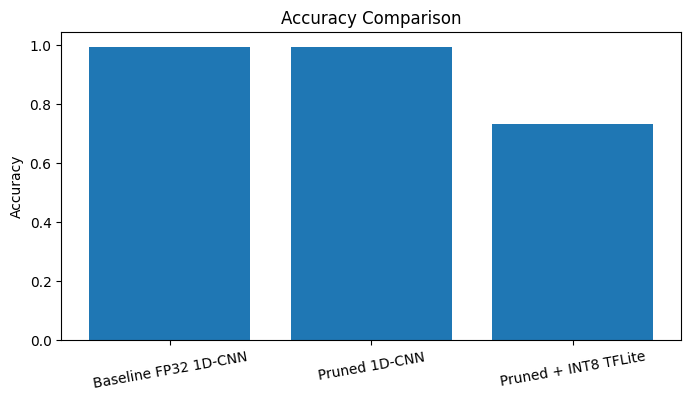

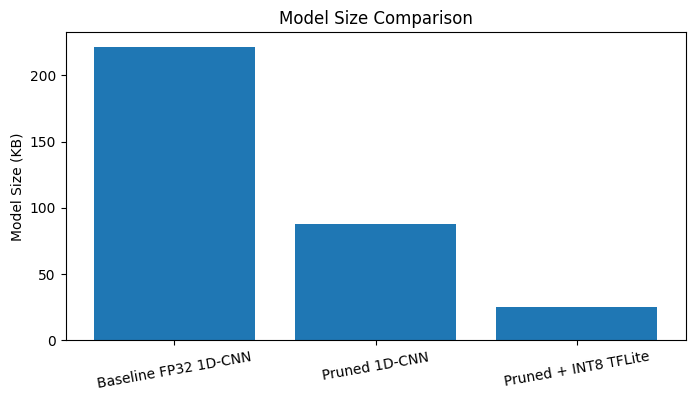

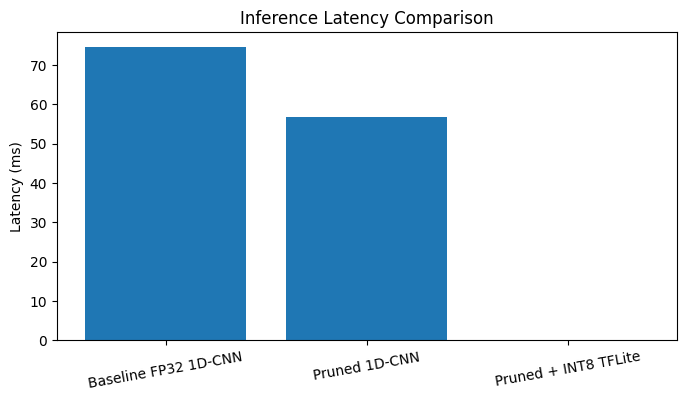

In [ ]:

plt.figure(figsize=(8, 4))
plt.bar(comparison_df['model'], comparison_df['accuracy'])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(rotation=10)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df['model'], comparison_df['size_kb'])
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=10)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison_df['model'], comparison_df['latency_ms_per_sample'])
plt.ylabel("Latency (ms)")
plt.title("Inference Latency Comparison")
plt.xticks(rotation=10)
plt.show()


## 17. Expected observations

Typical behavior after compression:

- Pruning reduces parameter count and model size.
- INT8 quantization significantly reduces model size and improves inference speed.
- Accuracy may decrease slightly after aggressive compression.
- Raspberry Pi deployment usually benefits more from quantization than desktop CPU execution.

For deployment experiments, measure:
- End-to-end latency
- CPU utilization
- Memory usage
- Real-time throughput
